## Part 4: Choose your own advecnture! (7 Points; Optional for Extra Credit)

This section is open ended and your chance to explare any advanced analysis. Please perform any additional analysis you find interesting! Suggested analyses (only do one max):

- Topic evolution over time - see https://maartengr.github.io/BERTopic/getting_started/topicsovertime/topicsovertime.html#visualization 
- Word frequency over time - does the frequency of certain words change over time
- Semantic similarity - investigate similarity within and between presidents or time periods. For example, similarity between one presidents speeches, e.g. are all of Biden's speeches similar to each other? How similar are they to Trump's speeches? Are speeches from the 2000s more similar to each other than speeches in the 1800s? Which two presidents have the most similar speeches? See https://spacy.io/usage/linguistic-features#vectors-similarity 
-  Named Entity Recognition - which entity types are most common in speeches? What are the most common words for each entity type - see https://spacy.io/usage/linguistic-features#named-entities 
- Classification - can you build a classifier to detect democratic versus republican state of the union speeches from 1980-2024 - see https://scikit-learn.org/stable/auto_examples/text/plot_document_classification_20newsgroups.html#sphx-glr-auto-examples-text-plot-document-classification-20newsgroups-py 

In [2]:
import pandas as pd

sou = pd.read_csv("data/SOTU.csv")

sou_21cen = sou[sou["Year"] >= 2000].reset_index(drop=True)

In [9]:
import spacy
from tqdm import tqdm

nlp = spacy.load("en_core_web_sm")

# process speeches
processed_speech = [nlp(text) for text in tqdm(sou_21cen["Text"])]

100%|██████████| 25/25 [00:25<00:00,  1.03s/it]


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(sou_21cen["Text"])


tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

# add president label
tfidf_df["President"] = sou_21cen["President"].values
tfidf_df.head()

,000,10,100,100th,102,108,10th,11,110,110th,...,youth,zarqawi,zealand,zeitchik,zelenskiy,zero,zimbabwe,zone,zones,President
0,0.055516,0.018512,0.021694,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.032689,0.0,0.000000,0.000000,Joseph R. Biden
1,0.076510,0.044646,0.005232,0.000000,0.0,0.0,0.0,0.017789,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.015768,0.0,0.000000,0.000000,Joseph R. Biden
2,0.044877,0.005237,0.006138,0.000000,0.0,0.0,0.0,0.013912,0.0,0.0,...,0.000000,0.0,0.015998,0.0,0.031997,0.009249,0.0,0.000000,0.000000,Joseph R. Biden
3,0.044969,0.026240,0.067655,0.000000,0.0,0.0,0.0,0.020911,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.009267,0.0,0.032062,0.000000,Joseph R. Biden
4,0.080577,0.023509,0.027552,0.015911,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.012421,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.047734,Donald J. Trump


In [12]:
# group by president and obtain means
president_vectors = tfidf_df.groupby("President").mean()
president_vectors

,000,10,100,100th,102,108,10th,11,110,110th,...,youngstown,youth,zarqawi,zealand,zeitchik,zelenskiy,zero,zimbabwe,zone,zones
President,,,,,,,,,,,,,,,,,,,,,
Barack Obama,0.026314,0.022549,0.005636,0.000000,0.002483,0.000000,0.002368,0.008653,0.000000,0.000000,...,0.004299,0.000000,0.000000,0.000,0.000000,0.000000,0.004117,0.000000,0.000000,0.000000
Donald J. Trump,0.053210,0.015761,0.014986,0.009287,0.000000,0.000000,0.000000,0.011362,0.000000,0.000000,...,0.000000,0.014900,0.000000,0.000,0.010049,0.000000,0.000000,0.000000,0.000000,0.011934
George W. Bush,0.028416,0.014781,0.005140,0.000000,0.000000,0.002434,0.000000,0.005994,0.000000,0.002617,...,0.000000,0.008118,0.007038,0.000,0.000000,0.000000,0.003688,0.004899,0.000000,0.000000
Joseph R. Biden,0.055468,0.023659,0.025180,0.000000,0.000000,0.000000,0.000000,0.013153,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.004,0.000000,0.007999,0.016743,0.000000,0.008016,0.000000
William J. Clinton,0.077195,0.037933,0.022228,0.000000,0.000000,0.000000,0.000000,0.000000,0.014484,0.000000,...,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012837


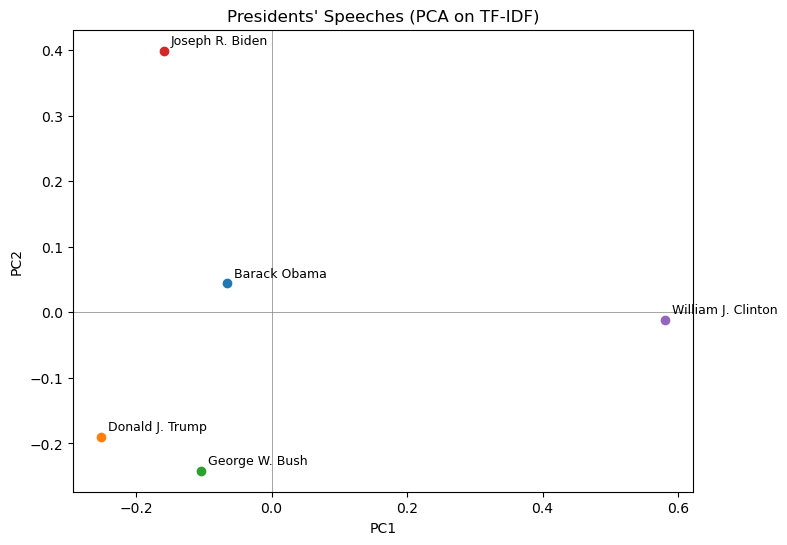

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# plot pca analysis -- which presidents had most similar speeches
pca = PCA(n_components=2)
coords = pca.fit_transform(president_vectors)

pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"],
                      index=president_vectors.index)

plt.figure(figsize=(8,6))
for name, row in pca_df.iterrows():
    plt.scatter(row["PC1"], row["PC2"])
    plt.text(row["PC1"] + 0.01, row["PC2"] + 0.01, name, fontsize=9)

plt.title("Presidents' Speeches (PCA on TF-IDF)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axhline(0, color = "gray", linewidth=0.5)
plt.axvline(0, color = "gray", linewidth=0.5)
plt.show()

The PCA plot shows Biden and Obama close together, reflecting similar modern Democratic language and overlapping vocabulary (of course, they of course also shared two terms together). Trump and Bush cluster nearer each other, suggesting overlap in Republican themes. Interestingly, Clinton appears farther from both groups, likely because his speeches predate the 2000s shift in political language (i.e. pre-9/11), making his rhetorical style more distinct.